In [7]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("retail_sales_dataset.csv")

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

print(df.head())
print(df.dtypes)

    order_id order_date customer_id customer_name   age gender   region  \
0  ORD-03903 2024-08-15   CUST32603   Aarav Mehta  39.0  Other  Central   
1  ORD-02198 2022-08-16   CUST07881  Sanjay Verma  28.0   Male     West   
2  ORD-01348 2021-08-29   CUST49296  Pooja Sharma  41.0  Other     West   
3  ORD-02076 2022-07-05   CUST05587   Priya Reddy  29.0  Other     West   
4  ORD-00287 2020-05-07   CUST58035   Ritu Sharma   9.0   Male  Central   

        city product_category product_name  ...  unit_price  discount_pct  \
0     Raipur        Groceries        Sugar  ...      346.32           NaN   
1     Mumbai           Beauty    Sunscreen  ...      858.66          0.08   
2      Surat        Furniture         Sofa  ...    25941.32          0.14   
3  Ahmedabad        Furniture    Bed Frame  ...    22071.92          0.17   
4     Nagpur        Groceries  Cooking Oil  ...      320.06          0.31   

   sales_amount    profit  shipping_cost  payment_method  \
0       4043.14    289.18 

In [8]:
print("Shape:", df.shape)
df.info()
df.isnull().sum()
df[df.isnull().sum(axis=1) > 5]
df.isnull().sum()
df.describe(include="all")

Shape: (4310, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               4280 non-null   object        
 1   order_date             4007 non-null   datetime64[ns]
 2   customer_id            4280 non-null   object        
 3   customer_name          4280 non-null   object        
 4   age                    4150 non-null   float64       
 5   gender                 4280 non-null   object        
 6   region                 4280 non-null   object        
 7   city                   4280 non-null   object        
 8   product_category       4280 non-null   object        
 9   product_name           4280 non-null   object        
 10  quantity               4170 non-null   float64       
 11  unit_price             4280 non-null   float64       
 12  discount_pct           4143 non-null   float

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
count,4280,4007,4280,4280,4150.000000,4280,4280,4280,4280,4280,...,4280.000000,4143.000000,4.280000e+03,4.280000e+03,4280.000000,4280,3932.000000,4280,4280,4180.000000
unique,4200,NaN,4112,400,NaN,11,5,20,7,42,...,NaN,NaN,NaN,NaN,NaN,6,NaN,2,9,NaN
top,ORD-02268,NaN,CUST85913,Priya Verma,NaN,Other,South,Amritsar,Clothing,Dal (1kg),...,NaN,NaN,NaN,NaN,NaN,UPI,NaN,False,Delivered,NaN
freq,2,NaN,3,21,NaN,1442,885,242,645,120,...,NaN,NaN,NaN,NaN,NaN,761,NaN,3657,2666,NaN
mean,NaN,2022-07-05 03:06:09.253805824,NaN,NaN,35.335181,NaN,NaN,NaN,NaN,NaN,...,10621.154428,0.202085,6.235864e+04,1.168713e+04,63.358836,NaN,3.016531,NaN,NaN,5.620335
min,NaN,2020-01-01 00:00:00,NaN,NaN,-7.000000,NaN,NaN,NaN,NaN,NaN,...,50.260000,0.000000,3.945000e+01,1.560000e+00,-4.290000,NaN,1.000000,NaN,NaN,-1.000000
25%,NaN,2021-04-18 00:00:00,NaN,NaN,26.000000,NaN,NaN,NaN,NaN,NaN,...,672.222500,0.100000,2.462165e+03,7.018225e+02,50.817500,NaN,2.000000,NaN,NaN,3.000000
50%,NaN,2022-07-10 00:00:00,NaN,NaN,34.000000,NaN,NaN,NaN,NaN,NaN,...,2228.435000,0.210000,9.548075e+03,3.128005e+03,63.465000,NaN,3.000000,NaN,NaN,6.000000
75%,NaN,2023-09-27 12:00:00,NaN,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,...,12717.435000,0.310000,5.006964e+04,1.040372e+04,75.650000,NaN,4.000000,NaN,NaN,8.000000
max,NaN,2024-12-30 00:00:00,NaN,NaN,999.000000,NaN,NaN,NaN,NaN,NaN,...,79957.920000,0.400000,1.736031e+07,2.445648e+06,133.350000,NaN,5.000000,NaN,NaN,100.000000


In [9]:
# 1. Drop the 30 blank/junk rows
df = df.dropna(subset=['order_id', 'order_date', 'customer_id']).copy()
print(df.shape)   # should now be ~4280 rows

# 2. Confirm what's left
df.isnull().sum()

# 3. Handle the remaining scattered nulls
df['age'] = df['age'].fillna(df['age'].median())
df['quantity'] = df['quantity'].fillna(df['quantity'].median())
df['discount_pct'] = df['discount_pct'].fillna(0)          # judgment call — see note below
df['customer_satisfaction'] = df['customer_satisfaction'].fillna(df['customer_satisfaction'].median())
df['days_to_ship'] = df['days_to_ship'].fillna(df['days_to_ship'].median())

df.isnull().sum()   # should now be all zeros

(4007, 21)


order_id                 0
order_date               0
customer_id              0
customer_name            0
age                      0
gender                   0
region                   0
city                     0
product_category         0
product_name             0
quantity                 0
unit_price               0
discount_pct             0
sales_amount             0
profit                   0
shipping_cost            0
payment_method           0
customer_satisfaction    0
return_flag              0
order_status             0
days_to_ship             0
dtype: int64

In [10]:
print("return_flag:",df['return_flag'].unique())
print("order_status:",df['order_status'].unique())
print("customer_satisfaction:",df['customer_satisfaction'].unique())

return_flag: [True False]
order_status: ['Returned' 'Delivered' 'Pending' 'Cancelled' 'Shipped' 'delivered'
 'cancelled' 'shipped' 'pending']
customer_satisfaction: [3. 5. 4. 1. 2.]


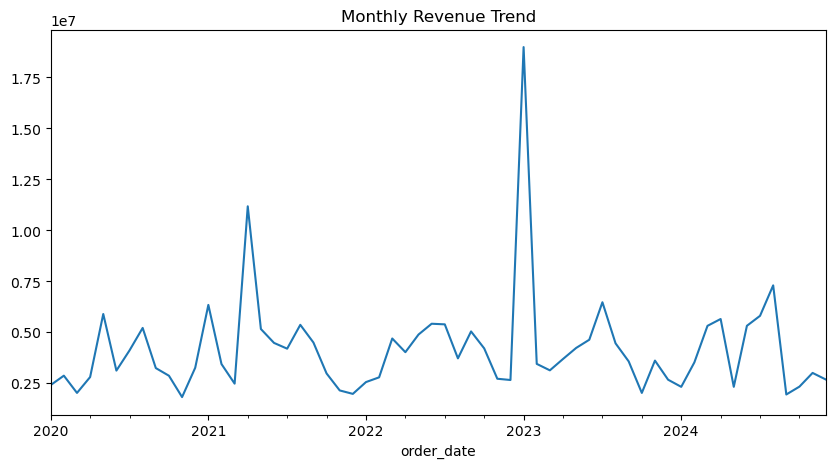

In [11]:
df.groupby(df['order_date'].dt.to_period('M'))['sales_amount'].sum().plot(
    kind='line', figsize=(10,5), title='Monthly Revenue Trend')
plt.show()

In [12]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
print(df['order_date'].dtype)
print(df['order_date'].isna().sum())  # how many dates failed to parse

datetime64[ns]
0


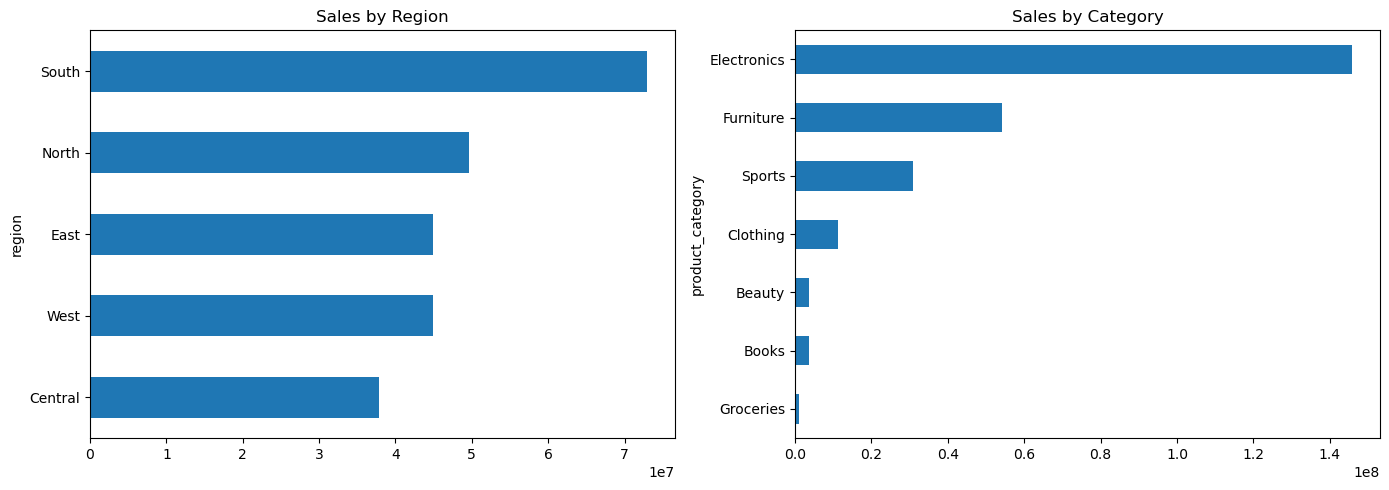

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df.groupby('region')['sales_amount'].sum().sort_values().plot(kind='barh', ax=axes[0], title='Sales by Region')
df.groupby('product_category')['sales_amount'].sum().sort_values().plot(kind='barh', ax=axes[1], title='Sales by Category')
plt.tight_layout()
plt.show()

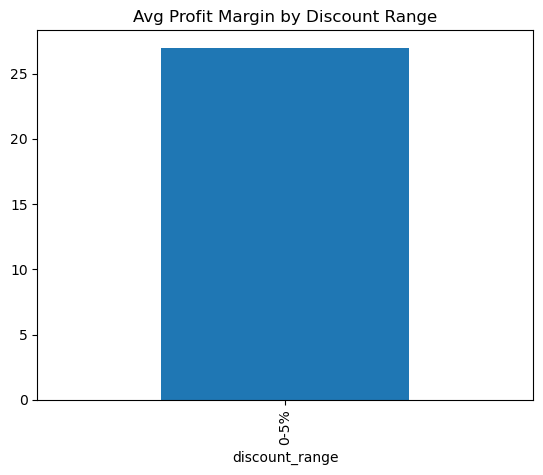

In [14]:
df['profit_margin_pct'] = (df['profit'] / df['sales_amount']) * 100
bins = [0, 5, 10, 15, 20, 30, 50, 100]
labels = ['0-5%','5-10%','10-15%','15-20%','20-30%','30-50%','50%+']
df['discount_range'] = pd.cut(df['discount_pct'], bins=bins, labels=labels, include_lowest=True)

df.groupby('discount_range', observed=True)['profit_margin_pct'].mean().plot(
    kind='bar', title='Avg Profit Margin by Discount Range')
plt.show()

In [15]:
print(df['return_flag'].unique())

print(df['return_flag'].isnull().sum())

[True False]
0


In [16]:
df['return_flag'] = df['return_flag'].astype(int)
print(df['return_flag'].unique())
print(df['return_flag'].isnull().sum())

[1 0]
0


In [17]:
# Build features (leakage-safe)
features = ['product_category', 'region', 'unit_price', 'discount_pct',
            'shipping_cost', 'days_to_ship', 'payment_method', 'age', 'gender', 'quantity']

X = pd.get_dummies(df[features], columns=['product_category', 'region', 'payment_method', 'gender'], drop_first=True)
y = df['return_flag']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92       685
           1       1.00      0.03      0.05       117

    accuracy                           0.86       802
   macro avg       0.93      0.51      0.49       802
weighted avg       0.88      0.86      0.80       802

[[685   0]
 [114   3]]


In [21]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(10))

unit_price       0.146621
shipping_cost    0.140624
age              0.127300
discount_pct     0.122510
quantity         0.086074
days_to_ship     0.083231
gender_Other     0.018811
region_West      0.017581
region_South     0.017148
gender_Male      0.016841
dtype: float64


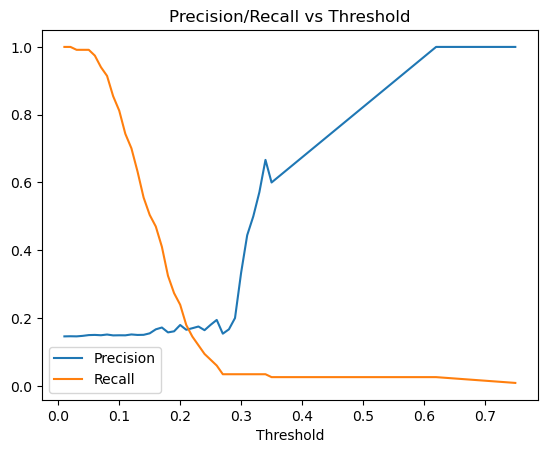

In [22]:
y_probs = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold'); plt.legend(); plt.title('Precision/Recall vs Threshold')
plt.show()


In [23]:
y_pred_adj = (y_probs >= 0.3).astype(int)
print(classification_report(y_test, y_pred_adj))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       685
           1       0.33      0.03      0.06       117

    accuracy                           0.85       802
   macro avg       0.60      0.51      0.49       802
weighted avg       0.78      0.85      0.79       802



In [24]:
y_probs = model.predict_proba(X_test)[:, 1]
y_pred_adj = (y_probs >= 0.3).astype(int)
print(classification_report(y_test, y_pred_adj))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       685
           1       0.33      0.03      0.06       117

    accuracy                           0.85       802
   macro avg       0.60      0.51      0.49       802
weighted avg       0.78      0.85      0.79       802



In [25]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, y_probs))


0.5308191403081914


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression benefits from scaled numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

y_probs_log = log_model.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import roc_auc_score, classification_report
print("ROC-AUC:", roc_auc_score(y_test, y_probs_log))
print(classification_report(y_test, log_model.predict(X_test_scaled)))

ROC-AUC: 0.5088402270884023
              precision    recall  f1-score   support

           0       0.85      0.54      0.66       685
           1       0.14      0.45      0.22       117

    accuracy                           0.53       802
   macro avg       0.50      0.50      0.44       802
weighted avg       0.75      0.53      0.60       802



In [27]:




##Two independent model types, same conclusion: return behavior in this dataset isn't predictable from price,
##shipping, discount, quantity, timing, or demographics.
##Because that we're doing now Revenue Forecasting 





In [28]:
#Check date range
print(df['order_date'].min(), df['order_date'].max())
print(df['order_date'].dt.to_period('M').nunique(), "months of data")

2020-01-01 00:00:00 2024-12-30 00:00:00
60 months of data


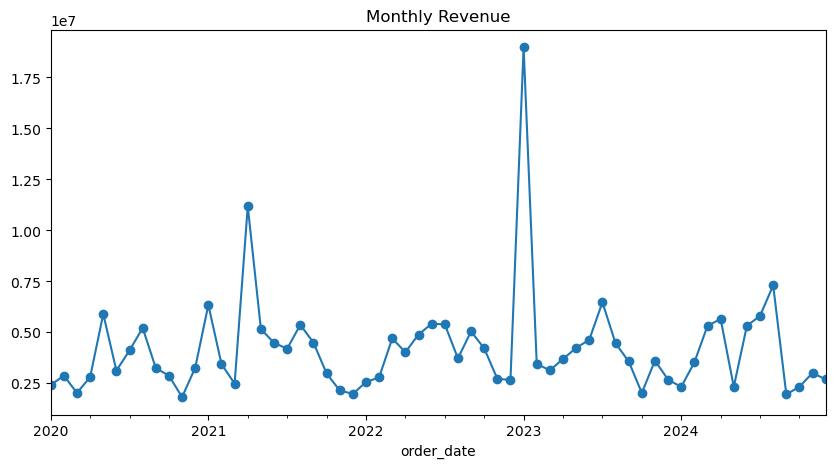

In [29]:
monthly_revenue = df.groupby(df['order_date'].dt.to_period('M'))['sales_amount'].sum()
monthly_revenue.index = monthly_revenue.index.to_timestamp()

monthly_revenue.plot(figsize=(10,5), title='Monthly Revenue', marker='o')
plt.show()

In [30]:
n_test = 3  # adjust based on the month count from Step 1
train = monthly_revenue[:-n_test]
test = monthly_revenue[-n_test:]


In [31]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ts_model = ExponentialSmoothing(train, trend='add', seasonal=None)
ts_fit = ts_model.fit()

forecast = ts_fit.forecast(n_test)
print(forecast)

2024-10-01    5.299953e+06
2024-11-01    5.345424e+06
2024-12-01    5.390895e+06
Freq: MS, dtype: float64


MAE: 2674332.250575639


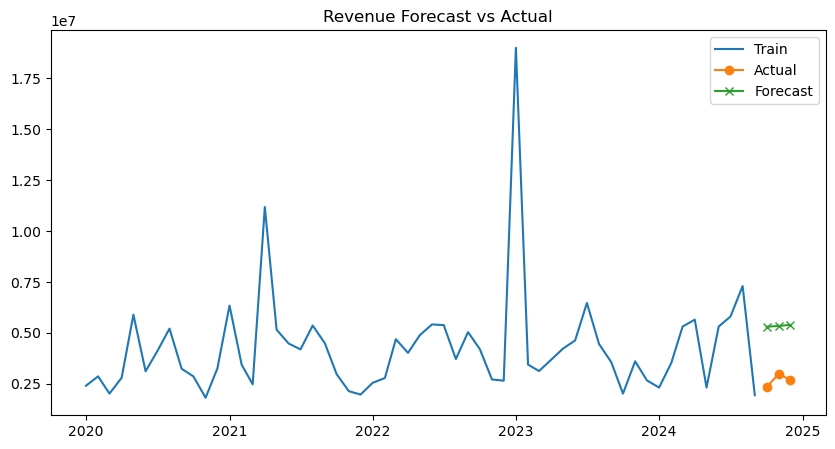

In [32]:
import numpy as np

mae = np.mean(np.abs(forecast.values - test.values))
print("MAE:", mae)

plt.figure(figsize=(10,5))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Actual', marker='o')
plt.plot(test.index, forecast.values, label='Forecast', marker='x')
plt.legend()
plt.title('Revenue Forecast vs Actual')
plt.show()

In [33]:
print(test)

order_date
2024-10-01    2329721.93
2024-11-01    3002304.37
2024-12-01    2681249.55
Freq: MS, Name: sales_amount, dtype: float64


In [34]:
ts_model_seasonal = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
ts_fit_seasonal = ts_model_seasonal.fit()

forecast_seasonal = ts_fit_seasonal.forecast(n_test)
print(forecast_seasonal)

mae_seasonal = np.mean(np.abs(forecast_seasonal.values - test.values))
print("Seasonal MAE:", mae_seasonal)


2024-10-01    4.113797e+06
2024-11-01    3.031720e+06
2024-12-01    3.472128e+06
Freq: MS, dtype: float64
Seasonal MAE: 868123.1776281218


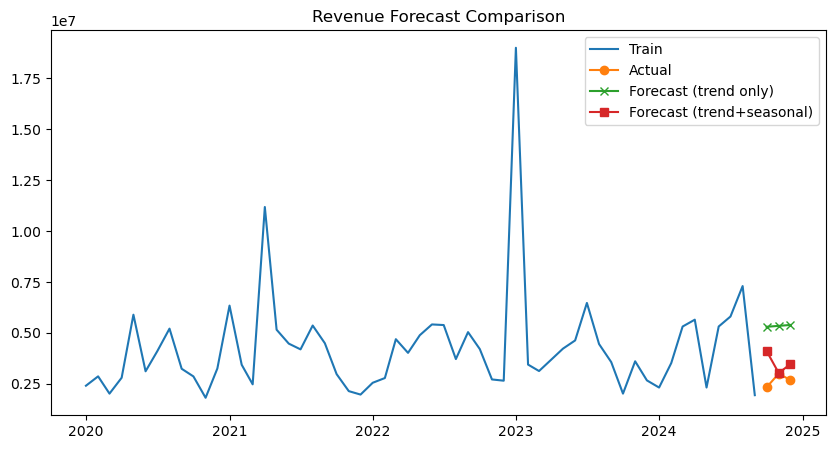

In [35]:
plt.figure(figsize=(10,5))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Actual', marker='o')
plt.plot(test.index, forecast.values, label='Forecast (trend only)', marker='x')
plt.plot(test.index, forecast_seasonal.values, label='Forecast (trend+seasonal)', marker='s')
plt.legend()
plt.title('Revenue Forecast Comparison')
plt.show()

In [36]:
ts_model_mult = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12)
ts_fit_mult = ts_model_mult.fit()

forecast_mult = ts_fit_mult.forecast(n_test)
print(forecast_mult)

mae_mult = np.mean(np.abs(forecast_mult.values - test.values))
print("Multiplicative Seasonal MAE:", mae_mult)

2024-10-01    2.821989e+06
2024-11-01    2.845220e+06
2024-12-01    2.851745e+06
Freq: MS, dtype: float64
Multiplicative Seasonal MAE: 273282.2663618924


2025-01-01    7.997061e+06
2025-02-01    3.311019e+06
2025-03-01    3.865771e+06
2025-04-01    6.013525e+06
2025-05-01    4.712984e+06
2025-06-01    5.063404e+06
Freq: MS, dtype: float64


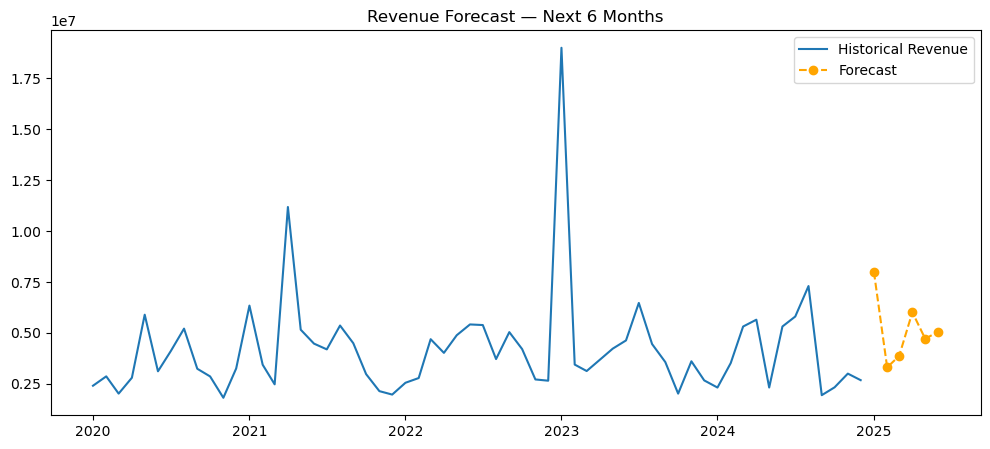

In [38]:
final_ts_model = ExponentialSmoothing(monthly_revenue, trend='add', seasonal='mul', seasonal_periods=12)
final_ts_fit = final_ts_model.fit()

future_forecast = final_ts_fit.forecast(6)   # next 6 months beyond Dec 2024
print(future_forecast)

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue.index, monthly_revenue.values, label='Historical Revenue')
plt.plot(future_forecast.index, future_forecast.values, label='Forecast', linestyle='--', marker='o', color='orange')
plt.legend()
plt.title('Revenue Forecast — Next 6 Months')
plt.show()